# Sample 3 — Scaled dot-product attention, by hand

This is the notebook to slow down on. Everything is kept tiny — 4 tokens, `d_model = 4` — and
every intermediate matrix is printed, so you can pick a single number out of any array here and
recompute it yourself with a calculator.

**Goal:** compute `Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V` one step at a time.


## 1. Input

Same setup as `sample-2`: 4 tokens, each already turned into a `d_model = 4` vector (token
embedding + positional encoding). We recompute it here so this notebook stands on its own.

In [1]:
import numpy as np

rng = np.random.default_rng(seed=0)

words = ["the", "cat", "sat", "mat"]
seq_len, d_model = len(words), 4

# Stand-in for "embedding + positional encoding" from sample-2 — what matters here
# is just that X is a (seq_len, d_model) matrix of numbers, one row per token.
X = rng.normal(loc=0.0, scale=0.5, size=(seq_len, d_model)).round(2)
print("X shape:", X.shape)
X


X shape: (4, 4)


array([[ 0.06, -0.07,  0.32,  0.05],
       [-0.27,  0.18,  0.65,  0.47],
       [-0.35, -0.63, -0.31,  0.02],
       [-1.16, -0.11, -0.62, -0.37]])

## 2. Project to Query, Key, Value

Attention doesn't use `X` directly — it first projects every token vector into three different
spaces using three learned weight matrices, all of shape `(d_model, d_model)` here:

- `Q = X W_Q` — "what am I looking for?"
- `K = X W_K` — "what do I contain, for others to match against?"
- `V = X W_V` — "what do I actually offer, if attended to?"

Each is just a matrix multiplication — every row of `Q` is a linear combination of a row of `X`
with the columns of `W_Q`.

In [2]:
W_Q = rng.normal(scale=0.5, size=(d_model, d_model)).round(2)
W_K = rng.normal(scale=0.5, size=(d_model, d_model)).round(2)
W_V = rng.normal(scale=0.5, size=(d_model, d_model)).round(2)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("Q =\n", Q.round(2))
print("K =\n", K.round(2))
print("V =\n", V.round(2))


Q =
 [[ 0.12 -0.04 -0.11 -0.13]
 [ 0.25  0.25 -0.59 -0.45]
 [-0.01 -0.39  0.24 -0.15]
 [ 0.13  0.04  0.21 -0.3 ]]
K =
 [[-0.18  0.26  0.23  0.13]
 [-0.39  0.34  0.82  0.8 ]
 [ 0.43 -0.3  -0.48 -0.64]
 [ 0.47 -0.72 -0.86 -0.9 ]]
V =
 [[ 0.11  0.1  -0.09 -0.17]
 [-0.21 -0.16 -0.14 -0.13]
 [-0.38 -0.56  0.54  0.18]
 [-1.09 -0.8  -0.09  0.97]]


In [3]:
# Hand-check: row 0 of Q should equal X[0] (a length-4 vector) dotted against
# each column of W_Q. Let's verify that by recomputing it with a plain Python loop.
row0_by_hand = [sum(X[0, k] * W_Q[k, j] for k in range(d_model)) for j in range(d_model)]
print("Q[0]        (matrix multiply):", Q[0].round(4))
print("Q[0]        (hand-computed)  :", np.array(row0_by_hand).round(4))
assert np.allclose(Q[0], row0_by_hand)


Q[0]        (matrix multiply): [ 0.1205 -0.0357 -0.1077 -0.1336]
Q[0]        (hand-computed)  : [ 0.1205 -0.0357 -0.1077 -0.1336]


## 3. Raw attention scores: `Q K^T`

For every pair of tokens `(i, j)`, the score `scores[i, j] = Q[i] . K[j]` — the dot product of
"what token `i` is looking for" with "what token `j` offers to be matched against". A higher dot
product means token `j` is more relevant to token `i`.

In [4]:
scores = Q @ K.T
print("scores shape:", scores.shape, " (seq_len, seq_len)")
scores.round(2)


scores shape: (4, 4)  (seq_len, seq_len)


array([[-0.07, -0.25,  0.2 ,  0.29],
       [-0.18, -0.86,  0.6 ,  0.85],
       [-0.06, -0.05,  0.09,  0.21],
       [-0.  , -0.11,  0.14,  0.12]])

In [5]:
# Hand-check scores[1, 2] = Q[1] . K[2], the dot product of two length-4 vectors
manual = sum(Q[1, k] * K[2, k] for k in range(d_model))
print("scores[1, 2] (matrix multiply):", round(scores[1, 2], 4))
print("scores[1, 2] (hand-computed)  :", round(manual, 4))


scores[1, 2] (matrix multiply): 0.6046
scores[1, 2] (hand-computed)  : 0.6046


## 4. Scale

Dot products grow with vector length — for large `d_model`, raw scores can get large enough that
softmax saturates (gradients vanish). Dividing by `sqrt(d_k)` (here `d_k = d_model = 4`) keeps the
scores in a well-behaved range regardless of dimensionality.

In [6]:
d_k = d_model
scaled_scores = scores / np.sqrt(d_k)
print(f"dividing by sqrt({d_k}) = {np.sqrt(d_k):.3f}")
scaled_scores.round(3)


dividing by sqrt(4) = 2.000


array([[-0.036, -0.127,  0.1  ,  0.147],
       [-0.088, -0.43 ,  0.302,  0.425],
       [-0.031, -0.026,  0.047,  0.103],
       [-0.002, -0.053,  0.068,  0.062]])

## 5. Softmax → attention weights

Softmax turns each *row* of scores into a probability distribution: values that sum to 1, with
larger scores getting proportionally more weight. We write it by hand rather than importing it
from anywhere:

```
softmax(x)_i = exp(x_i) / sum_j exp(x_j)
```

In [7]:
def softmax(x, axis=-1):
    # subtract the row max before exponentiating, purely for numerical stability
    # (does not change the result: softmax is shift-invariant)
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp = np.exp(shifted)
    return exp / np.sum(exp, axis=axis, keepdims=True)

attention_weights = softmax(scaled_scores, axis=-1)
print("attention_weights shape:", attention_weights.shape)
print("row sums (should all be 1.0):", attention_weights.sum(axis=1).round(6))
attention_weights.round(3)


attention_weights shape: (4, 4)
row sums (should all be 1.0): [1. 1. 1. 1.]


array([[0.235, 0.214, 0.269, 0.282],
       [0.206, 0.146, 0.304, 0.344],
       [0.236, 0.238, 0.256, 0.27 ],
       [0.245, 0.232, 0.262, 0.261]])

In [8]:
# Hand-check row 0 with plain Python exp/sum, no NumPy broadcasting tricks
row = scaled_scores[0]
exps = [np.exp(v) for v in row]
manual_row0 = [e / sum(exps) for e in exps]
print("row 0 (softmax fn)   :", attention_weights[0].round(6))
print("row 0 (hand-computed):", np.array(manual_row0).round(6))
assert np.allclose(attention_weights[0], manual_row0)


row 0 (softmax fn)   : [0.234693 0.214408 0.268907 0.281993]
row 0 (hand-computed): [0.234693 0.214408 0.268907 0.281993]


Row `i` of `attention_weights` says: when producing the output for token `i`, what fraction of
attention goes to each token `j` in the sequence (including itself). Let's look at it as a
heatmap — brighter means more attention.

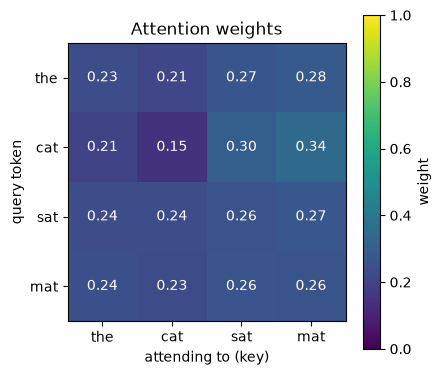

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(attention_weights, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(seq_len)); ax.set_xticklabels(words)
ax.set_yticks(range(seq_len)); ax.set_yticklabels(words)
ax.set_xlabel("attending to (key)")
ax.set_ylabel("query token")
ax.set_title("Attention weights")
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f"{attention_weights[i, j]:.2f}", ha="center", va="center",
                 color="white" if attention_weights[i, j] < 0.5 else "black")
fig.colorbar(im, ax=ax, label="weight")
plt.tight_layout()
plt.show()


## 6. Weighted sum of Value vectors

The final step: for each query token, blend the `V` rows together using that row of attention
weights as the blending coefficients — `output = attention_weights @ V`.

In [10]:
output = attention_weights @ V
print("output shape:", output.shape, " (same shape as V — one vector per token)")
output.round(3)


output shape: (4, 4)  (same shape as V — one vector per token)


array([[-0.431, -0.389,  0.068,  0.254],
       [-0.501, -0.45 ,  0.093,  0.335],
       [-0.418, -0.376,  0.059,  0.237],
       [-0.408, -0.37 ,  0.063,  0.228]])

In [11]:
# Hand-check output[0]: attention_weights[0] . V, column by column
manual_out0 = [sum(attention_weights[0, k] * V[k, j] for k in range(seq_len)) for j in range(d_model)]
print("output[0] (matrix multiply):", output[0].round(4))
print("output[0] (hand-computed)  :", np.array(manual_out0).round(4))
assert np.allclose(output[0], manual_out0)


output[0] (matrix multiply): [-0.4307 -0.3889  0.068   0.2544]
output[0] (hand-computed)  : [-0.4307 -0.3889  0.068   0.2544]


That's the entire mechanism: three projections, a scaled dot product, a softmax, and a weighted
sum. Every value above was small enough to double-check with a plain Python loop — a real model
does the exact same operations, just at a scale (thousands of dimensions, thousands of tokens)
where checking by hand is no longer practical.

**Next:** `sample-4-multi-head-attention` runs several of these attention computations in parallel,
each with its own `W_Q`/`W_K`/`W_V`, so the model can attend to different kinds of relationships
at once.